# Predicting the direction of price movement using machine learning algorithms

# Data Loading and Preparation

## Imports

In [ ]:
!pip install -q yfinance xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from xgboost import XGBClassifier

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize'] = (9, 4)

## Loading S&P 500 Data

I use the GSPC ticker (S&P 500 index) from Yahoo Finance.

Period: 5 full years — the first 4 years for training, the last year for testing.
I also load about 6 months of history before the start of the period as a warm-up buffer, so that the rolling indicators (MA49, MACD, RSI) are correctly computed by the first day of the training set.

In [ ]:
# Period
BUFFER_START = '2021-01-01'   # warm-up buffer for indicators
TRAIN_START  = '2021-07-01'   # start of training window (4 years)
SPLIT_DATE   = '2025-07-01'   # start of test window (last year)
DATA_END     = '2026-07-01'   # end of data


raw = yf.download('^GSPC', start=BUFFER_START, end=DATA_END, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [ ]:
df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,3764.6101,3769.9900,3662.7100,3700.6499,5015000000
2021-01-05,3698.0200,3737.8301,3695.0701,3726.8601,4591020000
2021-01-06,3712.2000,3783.0400,3705.3401,3748.1399,6064110000
2021-01-07,3764.7100,3811.5500,3764.7100,3803.7900,5099160000
2021-01-08,3815.0500,3826.6899,3783.6001,3824.6799,4773040000


In [ ]:
print(f'Number of rows: {len(df)}, period: {df.index.min().date()} — {df.index.max().date()}')

Number of rows: 1378, period: 2021-01-04 — 2026-06-30


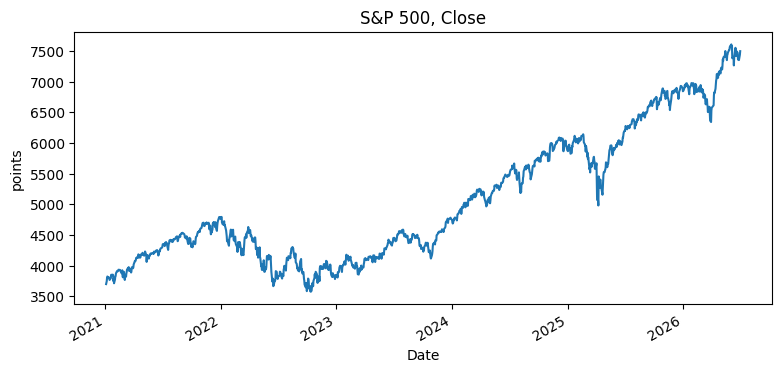

In [ ]:
df['Close'].plot(title='S&P 500, Close')
plt.ylabel('points')
plt.show()

## Target

- `target = 1` — the index will grow tomorrow
- `target = 0` — will fall tomorrow (or will not change)

In [ ]:
df['return'] = df['Close'].pct_change()
df['target'] = (df['return'].shift(-1) > 0).astype(int)
df = df.iloc[:-1]

print('Class balance (percentage of growth days):', df['target'].mean().round(4) * 100)

Class balance (percentage of growth days): 53.959999999999994


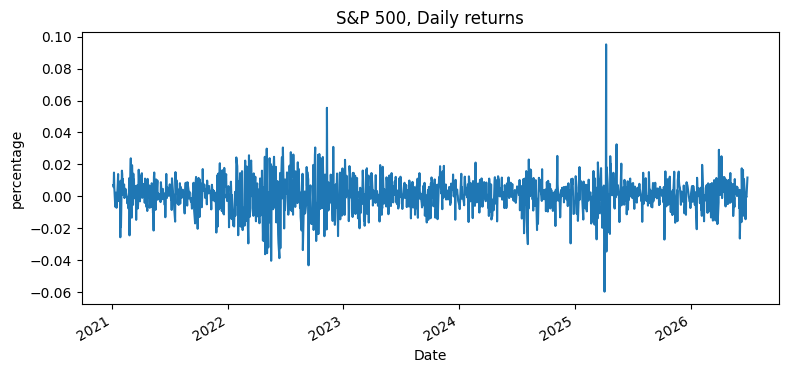

In [ ]:
df['return'].plot(title='S&P 500, Daily returns')
plt.ylabel('percentage')
plt.show()

## Predictors

Feature groups:

- **Lagged returns** — daily returns over the previous 1–6 days
- **Moving averages** — ratio of the closing price to its 7-, 14-, 21-, and 49-day moving averages
- **RSI** — 14-day Relative Strength Index (Wilder's smoothing)
- **MACD** — MACD line, signal line, and histogram (normalized by price)
- **Volatility** — standard deviation of daily returns over 5-day and 21-day windows

In [ ]:
features = pd.DataFrame(index=df.index)

# Lagged returns
for lag in range(1, 7):
    features[f'ret_lag_{lag}'] = df['return'].shift(lag - 1)

# Moving average
for w in [7, 14, 21, 49]:
    ma = df['Close'].rolling(w).mean()
    features[f'close_to_ma_{w}'] = df['Close'] / ma - 1

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
rs = avg_gain / avg_loss
features['rsi_14'] = 100 - 100 / (1 + rs)

# MACD (12, 26, 9)
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
macd_signal = macd_line.ewm(span=9, adjust=False).mean()
features['macd']        = macd_line / df['Close']
features['macd_signal'] = macd_signal / df['Close']
features['macd_hist']   = (macd_line - macd_signal) / df['Close']

# Volatility
features['vol_5']  = df['return'].rolling(5).std()
features['vol_21'] = df['return'].rolling(21).std()

FEATURE_NAMES = list(features.columns)
print(f'All features: {len(FEATURE_NAMES)}')
FEATURE_NAMES

All features: 16


['ret_lag_1',
 'ret_lag_2',
 'ret_lag_3',
 'ret_lag_4',
 'ret_lag_5',
 'ret_lag_6',
 'close_to_ma_7',
 'close_to_ma_14',
 'close_to_ma_21',
 'close_to_ma_49',
 'rsi_14',
 'macd',
 'macd_signal',
 'macd_hist',
 'vol_5',
 'vol_21']

In [ ]:
data = features.copy()
data['target'] = df['target']
data = data.dropna()
data = data.loc[TRAIN_START:]

print(f'Final dataset: {len(data)} rows, {data.index.min().date()} — {data.index.max().date()}')
data.head()

Final dataset: 1253 rows, 2021-07-01 — 2026-06-29


,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_lag_6,close_to_ma_7,close_to_ma_14,close_to_ma_21,close_to_ma_49,rsi_14,macd,macd_signal,macd_hist,vol_5,vol_21,target
Date,,,,,,,,,,,,,,,,,
2021-07-01,0.0052,0.0013,0.0003,0.0023,0.0033,0.0058,0.0084,0.0152,0.0175,0.0273,67.9395,0.0070,0.0056,0.0014,0.0019,0.0055,1
2021-07-02,0.0075,0.0052,0.0013,0.0003,0.0023,0.0033,0.0122,0.0211,0.0233,0.0341,71.9069,0.0079,0.0060,0.0019,0.0030,0.0055,0
2021-07-06,-0.0020,0.0075,0.0052,0.0013,0.0003,0.0023,0.0076,0.0174,0.0200,0.0313,69.3951,0.0085,0.0065,0.0019,0.0038,0.0053,1
2021-07-07,0.0034,-0.0020,0.0075,0.0052,0.0013,0.0003,0.0084,0.0186,0.0219,0.0339,71.1919,0.0090,0.0070,0.0020,0.0037,0.0053,0
2021-07-08,-0.0086,0.0034,-0.0020,0.0075,0.0052,0.0013,-0.0013,0.0082,0.0121,0.0243,61.2835,0.0088,0.0074,0.0014,0.0064,0.0058,1


## Train / test split
- **Train:** first 4 years
- **Test:** last year

In [ ]:
train = data.loc[data.index < SPLIT_DATE]
test  = data.loc[data.index >= SPLIT_DATE]

X_train, y_train = train[FEATURE_NAMES], train['target']
X_test,  y_test  = test[FEATURE_NAMES],  test['target']

print(f'Train: {len(train)} days ({train.index.min().date()} — {train.index.max().date()})')
print(f'Test:  {len(test)} days ({test.index.min().date()} — {test.index.max().date()})')
print(f'Proportion of growth days in train: {y_train.mean():.3f}, in test: {y_test.mean():.3f}')

Train: 1003 days (2021-07-01 — 2025-06-30)
Test:  250 days (2025-07-01 — 2026-06-29)
Proportion of growth days in train: 0.529, in test: 0.568


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
SCORING = 'roc_auc'

# Models

## Logistic Regression

In [ ]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, solver='saga')),
])

param_grid_lr = {
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        'model__class_weight': [None, 'balanced'],
}


gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=tscv,
                     scoring=SCORING, n_jobs=-1, refit=True)
gs_lr.fit(X_train, y_train)

print('Best params:', gs_lr.best_params_)
print(f'Best CV ROC-AUC: {gs_lr.best_score_:.4f}')
best_lr = gs_lr.best_estimator_

Best params: {'model__C': 0.001, 'model__class_weight': None, 'model__penalty': 'l1'}
Best CV ROC-AUC: 0.5000


## Random Forest

Hyperparameters tuned:

- `max_depth` — maximum tree depth (shallow trees generalize better on noisy data)
- `min_samples_leaf` — minimum number of samples per leaf (higher values = simpler trees)
- `max_features` — number of features considered at each split (`sqrt` is a standard default)
- `n_estimators` is fixed at 300

In [ ]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [300],
    'max_depth': [2, 3, 5],           # shallow trees generalize better on noisy data
    'min_samples_leaf': [5, 10, 20],      # main overfitting control
    'max_features': ['sqrt', 0.6],
    'class_weight': ['balanced'],
}

gs_rf = GridSearchCV(rf, param_grid_rf, cv=tscv,
                     scoring=SCORING, n_jobs=-1, refit=True)
gs_rf.fit(X_train, y_train)

print('Best params:', gs_rf.best_params_)
print(f'Best CV ROC-AUC: {gs_rf.best_score_:.4f}')
best_rf = gs_rf.best_estimator_

Best params: {'class_weight': 'balanced', 'max_depth': 2, 'max_features': 0.6, 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV ROC-AUC: 0.5052


## XGBoost

 The search space is explored with RandomizedSearchCV (random sampling from the ranges below), since a full grid over this many parameters would be too expensive.

 Hyperparameters tuned:

- `max_depth` — maximum tree depth (shallow trees generalize better on noisy data)
- `learning_rate` — contribution of each tree (smaller = more robust to noise, but needs more trees)
- `min_child_weight` — minimum sample weight per leaf, analogous to `min_samples_leaf` (higher values = simpler trees)
- `reg_lambda` — L2 regularization on leaf weights (shrinks large predictions)
- `reg_alpha` — L1 regularization (can drive feature contributions to zero)
- `gamma` — minimum loss reduction required to make a split (higher = fewer noise-driven splits)
- `scale_pos_weight` — class balancing (ratio of negative to positive class)
- `subsample` — fraction of rows sampled per tree (adds diversity, reduces overfitting)
- `colsample_bytree` — fraction of features sampled per tree
- `n_estimators` is fixed at 400

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=400
)

param_dist_xgb = {
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.09),
    'min_child_weight':  randint(1, 30),
    'reg_lambda':        uniform(0.5, 4.5),
    'reg_alpha':         uniform(0, 1.0),
    'gamma':             uniform(0, 2),
    'scale_pos_weight':  [1, 0.89],
    'subsample':         uniform(0.7, 0.3),
    'colsample_bytree':  uniform(0.7, 0.3),
}


rs_xgb = RandomizedSearchCV(xgb, param_dist_xgb, n_iter=120, cv=tscv, scoring=SCORING,
                            n_jobs=-1, refit=True, random_state=RANDOM_STATE,)
rs_xgb.fit(X_train, y_train)

print('Best parameters:', rs_xgb.best_params_)
print(f'Best CV ROC-AUC: {rs_xgb.best_score_:.4f}')
best_xgb = rs_xgb.best_estimator_

Best parameters: {'colsample_bytree': np.float64(0.9587091126240235), 'gamma': np.float64(1.8990412473152842), 'learning_rate': np.float64(0.023236613283613414), 'max_depth': 2, 'min_child_weight': 10, 'reg_alpha': np.float64(0.7689177413153975), 'reg_lambda': np.float64(0.7980619003333964), 'scale_pos_weight': 1, 'subsample': np.float64(0.994009772585643)}
Best CV ROC-AUC: 0.5350


# Evaluation
Consider accuracy, ROC-AUC, and confusion matrices,
and compare them with the naive baseline of always predict growth.

## Metrics

In [ ]:
models = {
    'Logistic Regression': best_lr,
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb,
}

rows = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy (test)': accuracy_score(y_test, y_pred),
        'ROC-AUC (test)':  roc_auc_score(y_test, y_proba),
        'ROC-AUC (CV)': {'Logistic Regression': gs_lr, 'Random Forest': gs_rf,
                               'XGBoost': rs_xgb}[name].best_score_,
    })

In [ ]:
# baseline
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
rows.append({'Model': 'Baseline',
             'Accuracy (test)': baseline_acc,
             'ROC-AUC (test)': 0.5,
             'ROC-AUC (CV)': np.nan})

In [ ]:
summary = pd.DataFrame(rows).set_index('Model')
print('Metrics')
summary

Metrics


,Accuracy (test),ROC-AUC (test),ROC-AUC (CV)
Model,,,
Logistic Regression,0.5680,0.5000,0.5000
Random Forest,0.5160,0.5035,0.5052
XGBoost,0.5120,0.5259,0.5350
Baseline,0.5680,0.5000,NaN


## Confusion matrix

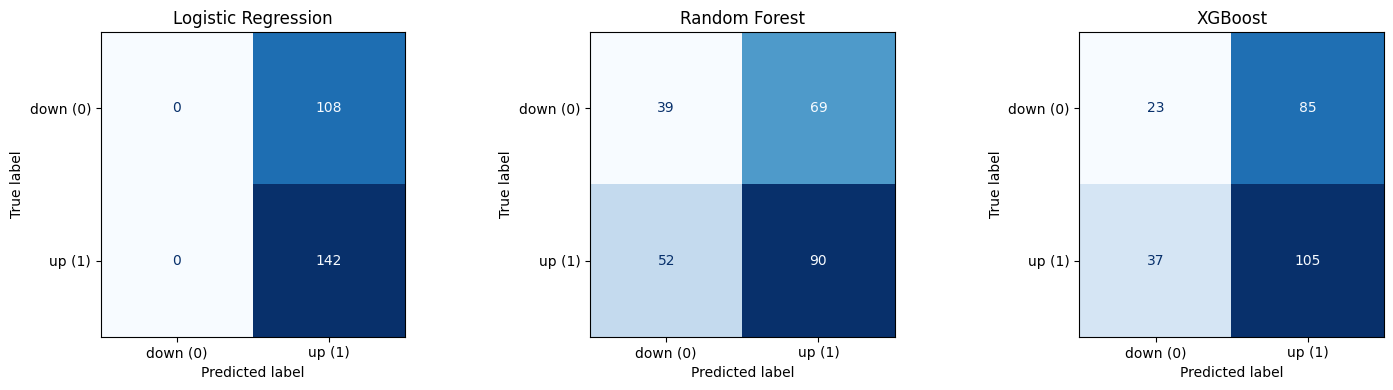

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['down (0)', 'up (1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Conclusion**

1. **No overfitting.** Train ROC-AUC does not exceed significantly test ROC-AUC for any model. For example: Random Forest scores 0.5052 on train vs 0.5035 on test, showing that the models generalise rather than memorise noise.

2. **All results are near-random.** ROC-AUC values barely exceed 0.5 and accuracy stays around 0.51–0.57, close to a baseline. XGBoost is the only model with a consistent (weak) signal, reaching ROC-AUC 0.5259 on the test set and above 0.5 on cross-validation.

3. **Logistic Regression collapses to the baseline.**
Its accuracy (0.5680) equals the constant "always up" baseline and its ROC-AUC is exactly 0.5. This is because L1 regularisation drove all coefficients to zero — the model became degenerate, predicting a single class. This is direct evidence that the selected features contain no usable linear signal for next-day direction.


**Possible reasons and next steps.** The daily direction of the S&P 500 is close to unpredictable from its own price history (consistent with the weak form of the efficient-market hypothesis), and the chosen technical indicators (lagged returns, moving averages, RSI, MACD, volatility) appear to carry little predictive power.



## Feature importances

For the random forest and XGBoost, we use the built-in attribute `feature_importances_`. Logistic regression does not have it — its analogue is shown separately as a magnitude
of standardized coefficients `|coef|`

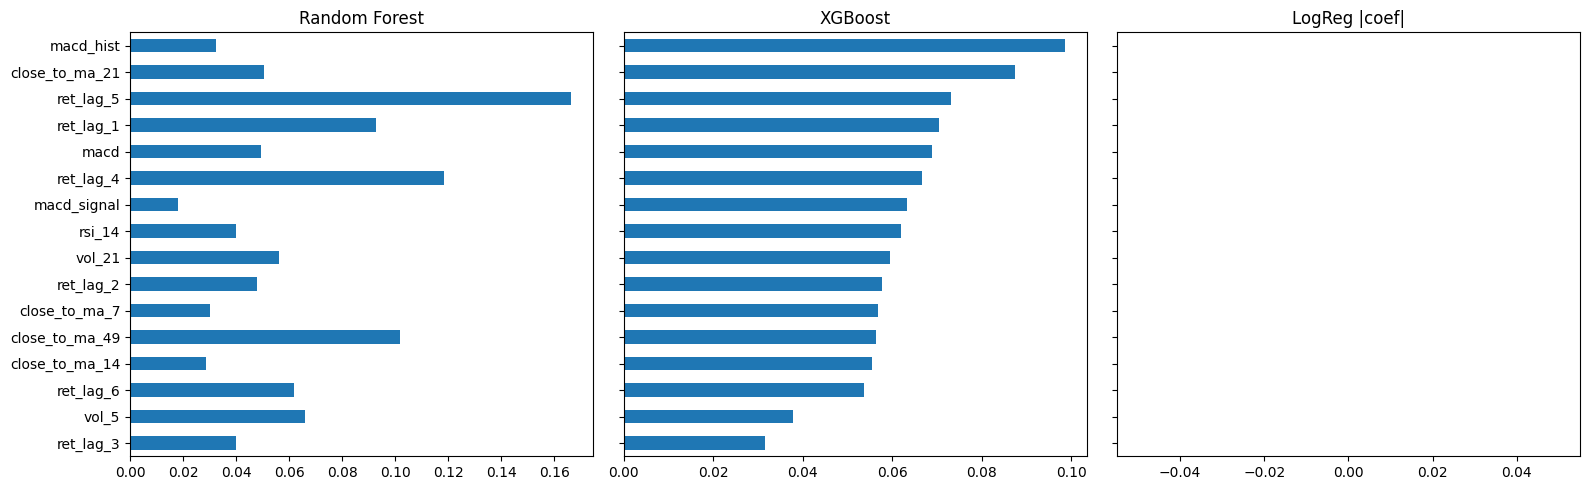

Top-5 features for models:

Random Forest:
ret_lag_5        0.1663
ret_lag_4        0.1185
close_to_ma_49   0.1019
ret_lag_1        0.0927
vol_5            0.0660

XGBoost:
macd_hist        0.0986
close_to_ma_21   0.0874
ret_lag_5        0.0732
ret_lag_1        0.0706
macd             0.0689

LogReg |coef|:
ret_lag_1   0.0000
ret_lag_2   0.0000
ret_lag_3   0.0000
ret_lag_4   0.0000
ret_lag_5   0.0000


In [ ]:
imp = pd.DataFrame(index=FEATURE_NAMES)
imp['Random Forest'] = best_rf.feature_importances_
imp['XGBoost']       = best_xgb.feature_importances_
imp['LogReg |coef|'] = np.abs(best_lr.named_steps['model'].coef_[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
order = imp['XGBoost'].sort_values().index
for ax, col in zip(axes, ['Random Forest', 'XGBoost', 'LogReg |coef|']):
    imp.loc[order, col].plot.barh(ax=ax, title=col)
plt.tight_layout()
plt.show()

print('Top-5 features for models:')
for col in imp.columns:
    top = imp[col].sort_values(ascending=False).head(5)
    print(f'\n{col}:')
    print(top.round(4).to_string())

**Conclusion**


1. **Logistic Regression — empty by construction.** The coefs panel is blank because L1 regularisation drove every coefficient to zero.

2. **XGBoost — nearly uniform importances.** Importance is spread almost evenly across all features (roughly 0.04–0.09 each), with no dominant predictor. A flat importance profile is itself informative: the model finds no single feature or small group carrying real predictive weight, consistent with its weak overall ROC-AUC (0.5282).

3. **Random Forest — dispersed but unreliable.** Random Forest assigns visibly higher importance to a few features (notably `ret_lag_5`, and some short-term lags and moving-average ratios). However, since the model itself performs at chance level (test ROC-AUC ≈ 0.50), these rankings largely reflect noise rather than genuine signal.